In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add

In [30]:
class BatsmanState(TypedDict):

    runs: Annotated[int, add]
    balls: Annotated[int, add]
    fours: Annotated[int, add]
    sixes: Annotated[int, add]

    sr: float
    boundary_per_balls: float
    boundary_percenatge: float
    summary: float

In [31]:
def calculate_sr(state: BatsmanState) -> BatsmanState:

    sr = (state['runs']/state['balls'])*100

    state['sr'] = sr

    return {'sr': sr}

In [32]:
def calculate_boundary_per_balls(state: BatsmanState) -> BatsmanState:

    boundaries = state['fours'] + state['sixes']

    bpb = state['balls'] / boundaries

    state['boundary_per_balls'] = bpb

    return {'boundary_per_balls': bpb}

In [33]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:

    total_boundary_runs = ((state['fours'] * 4) + (state['sixes'] * 6))

    percentage = (total_boundary_runs / state['runs']) * 100

    state['boundary_percenatge'] = percentage

    return {'boundary_percenatge': percentage}

In [34]:
def summary(state: BatsmanState) -> BatsmanState:

    return {
        'Strike Rate': state['sr'],
        'boundary_per_balls': state['boundary_per_balls'],
        "boundary_percenatge" : state['boundary_percenatge']
    }

In [35]:
graph = StateGraph(BatsmanState)

# add a node
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_boundary_per_balls', calculate_boundary_per_balls)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('summary',summary)

# add edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundary_per_balls')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_boundary_per_balls', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')

graph.add_edge('summary', END)

# compile a graph

workflow = graph.compile()

In [36]:
initial_state = {
    'runs': 120,
    'balls': 54,
    'fours': 8,
    'sixes': 10
}

In [37]:
workflow.invoke(initial_state)

{'runs': 120,
 'balls': 54,
 'fours': 8,
 'sixes': 10,
 'sr': 222.22222222222223,
 'boundary_per_balls': 3.0,
 'boundary_percenatge': 76.66666666666667}

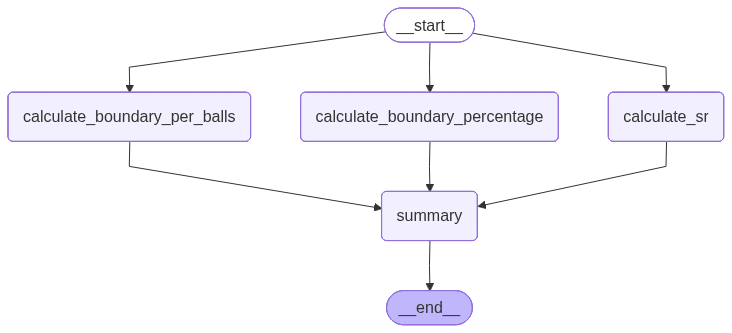

In [38]:
workflow